# *The Renovation Game* Monte Carlo Analysis

This notebook analyses Monte Carlo results for one version of the *Renovation Game* game model.

The main goals are to:

1. inspect whether the simulated game outcomes look plausible,
2. identify cards that are associated with better final performance,
3. distinguish common cards from cards that are disproportionately represented in good games,
4. account for whether cards were actually available to the player,
5. test whether results depend strongly on the chosen definition of an "elite" game.

## Important interpretation

`vp` denotes **Victory Points / CO₂ score**.  
**Lower VP is better.**

The card metrics in this notebook are primarily **descriptive associations**. In particular, `vp_lift` does not by itself prove that a card causally improves the outcome. A card may also be associated with better games because it is chosen in favourable states or as part of a successful combination of measures.


## 1. Setup

The notebook assumes it is run from the **repository root**.

Expected files:

```text
Versionen/paper_draft_v1/
├── game_data.xlsx
└── results/
    ├── games.parquet
    └── plays.parquet
```

`plays.parquet` is only available when the simulation was run with `log_choices=True`.


In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from model.game import load_game_data
from model.analysis import (
    game_summary,
    strategy_summary,
    card_analysis,
    card_elite_sensitivity,
    card_occurrence,
    card_elite_occurrence,
    card_enrichment,
    card_vp_lift,
    card_round_summary,
    card_opportunity_summary,
    plot_game_distributions,
    plot_vp_distribution,
    plot_state_vs_vp,
    plot_card_enrichment,
    plot_card_vp_lift,
)

version = Path("Versionen/paper_draft_v1")
results_dir = version / "results"

game_data = load_game_data(version)

games = pd.read_parquet(results_dir / "games.parquet")

plays_path = results_dir / "plays.parquet"
plays = pd.read_parquet(plays_path) if plays_path.exists() else pd.DataFrame()

print(f"{len(games):,} games loaded")
print(f"{len(plays):,} logged card decisions loaded")


10,000 games loaded
110,131 logged card decisions loaded


## 2. Basic simulation sanity checks

Before interpreting individual cards, inspect the overall simulation.

Useful questions:

- Is the VP range plausible?
- Do games normally survive all four rounds?
- Are final budget values plausible?
- Do thermal protection, electricity demand, generation, storage, and satisfaction occupy reasonable parts of their tracks?
- Are there obvious pile-ups at minimum or maximum values that could indicate clamping or lookup-table problems?


In [2]:
game_summary(games)

,count,mean,std,min,25%,50%,75%,max
vp,10000.0,360.0192,234.086281,-74.0,150.0,330.0,545.0,858.0
budget,10000.0,2.7123,4.967353,-16.0,2.0,4.0,5.0,15.0
n_cards_played,10000.0,8.8446,3.118754,0.0,7.0,9.0,11.0,19.0
rounds_played,10000.0,3.6727,0.843235,1.0,4.0,4.0,4.0,4.0
satisfaction,10000.0,3.0721,1.514705,0.0,2.0,3.0,4.0,9.0
thermal_protection,10000.0,3.0711,2.179798,0.0,1.0,3.0,5.0,9.0
electricity_demand,10000.0,5.7269,1.355470,2.0,5.0,6.0,7.0,9.0
electricity_generation,10000.0,2.6610,2.403135,0.0,1.0,1.0,4.0,9.0
storage,10000.0,5.7581,2.776248,0.0,4.0,6.0,9.0,9.0
grid_import,10000.0,6.9958,5.321298,-5.0,3.0,6.0,9.0,28.0


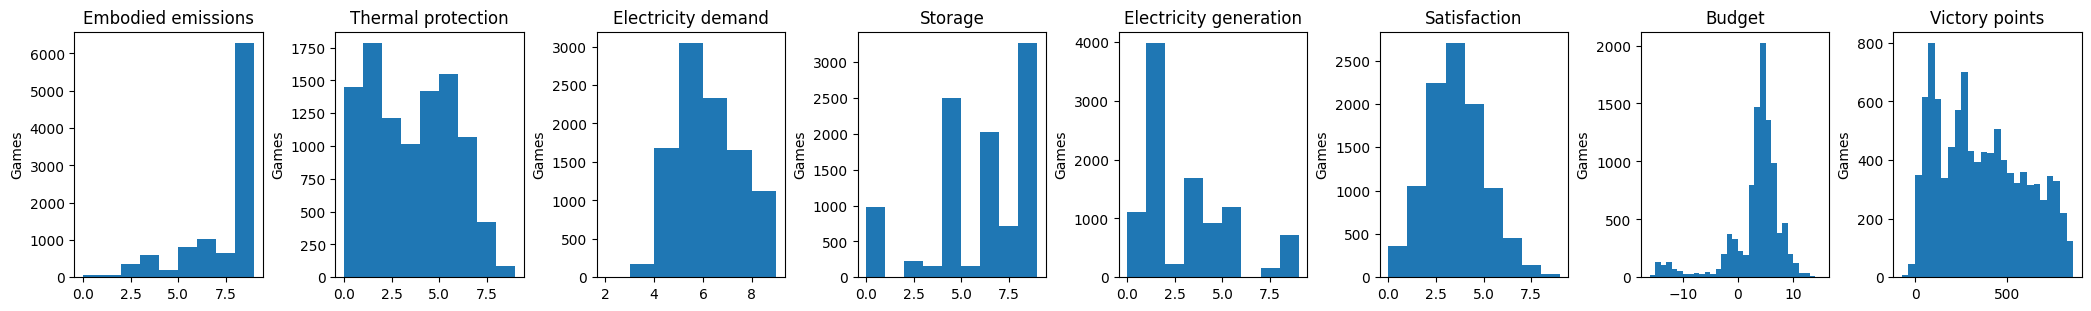

In [3]:
plot_game_distributions(games)
plt.show()

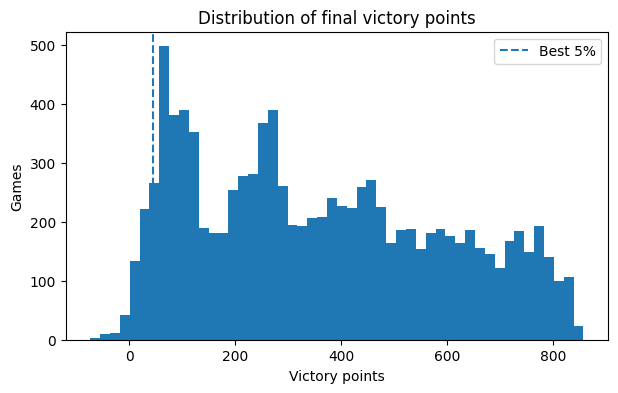

In [4]:
plot_vp_distribution(games, elite_share=0.05)
plt.show()

### State variables versus VP

These plots are useful for checking whether the direction of the model behaves as expected.

For example, if higher thermal protection generally leads to lower VP, this should be visible here. These plots are descriptive and do not control for interactions with other cards.


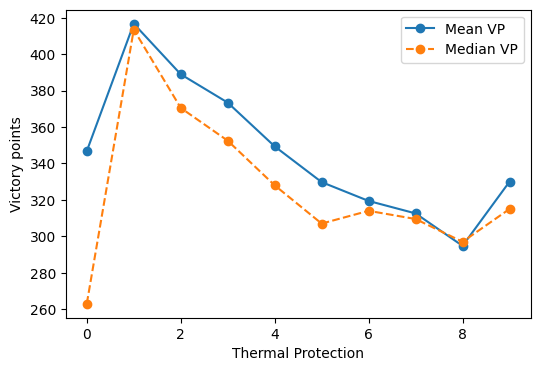

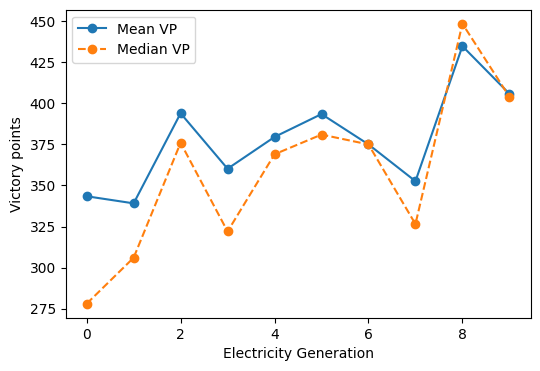

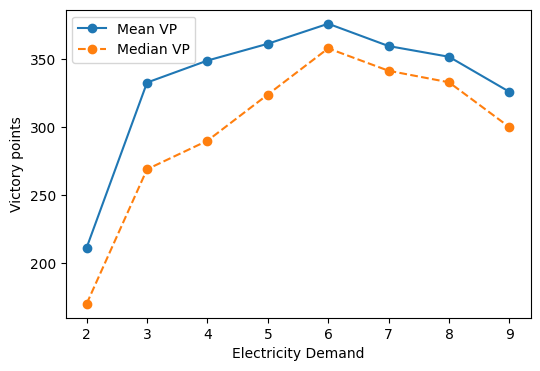

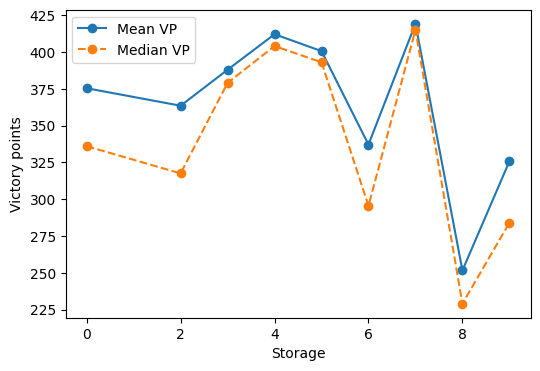

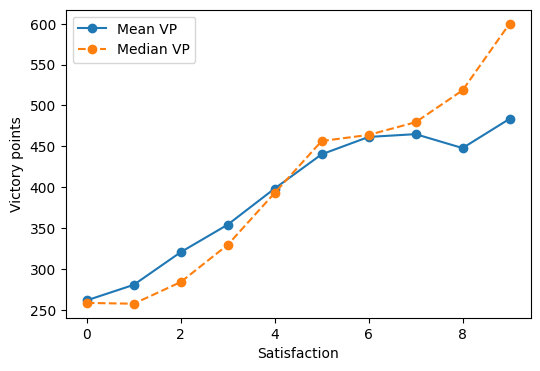

In [5]:
for variable in [
    "thermal_protection",
    "electricity_generation",
    "electricity_demand",
    "storage",
    "satisfaction",
]:
    if variable in games.columns:
        plot_state_vs_vp(games, variable)
        plt.show()

## 3. Combined card-effectiveness table

The main card-level table combines several complementary metrics.

### Occurrence

`occurrence` is the fraction of all games in which a card was played.

### Elite occurrence

`elite_occurrence` is the fraction of the best games containing the card.  
By default, the best **5%** of games are used.

### Enrichment

\[
\text{enrichment} =
\frac{P(\text{card} \mid \text{elite game})}
     {P(\text{card} \mid \text{all games})}
\]

Interpretation:

- `1.0`: card is equally common in elite and ordinary games
- `> 1.0`: card is overrepresented in elite games
- `< 1.0`: card is underrepresented in elite games

### VP lift

\[
\text{VP lift} =
\overline{VP}_{\text{without card}}
-
\overline{VP}_{\text{with card}}
\]

Because lower VP is better:

- **positive VP lift = associated with better games**
- negative VP lift = associated with worse games

The confidence interval is a descriptive normal-approximation interval around the difference in means.

### Selection rate

When detailed choice logging is available:

\[
\text{selection rate} =
\frac{\text{times selected}}
     {\text{times playable}}
\]

This helps distinguish a card that is rarely chosen because it is rarely available from one that is frequently available but usually ignored.


In [6]:
cards = card_analysis(
    games,
    plays=plays,
    game_data=game_data,
    elite_share=0.05,
)

cards

,card,occurrence,elite_occurrence,enrichment,elite_difference,games_with_card,games_without_card,mean_vp_with,mean_vp_without,vp_lift,...,times_played,mean_round,median_round,offered_opportunities,playable_opportunities,selected,selection_rate,label_en,category,copies
0,green_gas,0.0786,0.546,6.946565,0.4674,786,9214,222.839695,371.721294,148.881599,...,786,2.206107,2.0,110131,37033,786,0.021224,just use green gas!,Wärmeerzeugung,1
1,bidirectional_charging,0.0802,0.242,3.017456,0.1618,802,9198,324.693267,363.099369,38.406103,...,802,2.612219,3.0,110131,4132,802,0.194095,Bidirectional charging,*Flexibilität,1
2,ev_charging_infrastructure,0.1053,0.276,2.621083,0.1707,1053,8947,324.204179,364.234380,40.030202,...,1053,2.314340,2.0,110131,44970,1053,0.023416,E-car charging infrastructure,*Zufriedenheit,1
3,shower_water_heat_recovery,0.0694,0.136,1.959654,0.0666,694,9306,170.961095,374.118311,203.157216,...,694,3.119597,3.0,110131,18589,694,0.037334,Heat recovery from shower water,*Effizienz,1
4,groundwater_heat_pump,0.0796,0.116,1.457286,0.0364,796,9204,241.633166,370.257714,128.624548,...,796,2.125628,2.0,110131,37033,796,0.021494,Groundwater heat pump,Wärmeerzeugung,1
5,efficient_appliances,0.0736,0.098,1.331522,0.0244,736,9264,184.317935,373.978195,189.660260,...,736,3.187500,3.0,110131,18628,736,0.039510,Efficient appliances,*Flexibilität,1
6,conventional_facade_insulation_2,0.0589,0.076,1.290323,0.0171,589,9411,302.390492,363.625970,61.235477,...,589,2.230900,2.0,110131,28866,589,0.020405,Conventional facade insulation,Dämmung,1
7,thermal_flexibility,0.3351,0.368,1.098180,0.0329,3351,6649,233.113101,423.978042,190.864941,...,3351,2.485825,2.0,110131,17887,3351,0.187343,Thermal flexibility,*Flexibilität,1
8,wastewater_heat_pump,0.0529,0.058,1.096408,0.0051,529,9471,228.054820,367.390033,139.335212,...,529,2.028355,2.0,110131,26407,529,0.020033,Wastewater heat pumps,Wärmeerzeugung,1
9,ev_wallboxes,0.2067,0.204,0.986938,-0.0027,2067,7933,341.422351,364.864742,23.442391,...,2067,2.552008,3.0,110131,65198,2067,0.031703,E-car wall boxes,*Zufriedenheit,1


## 4. Which cards are most strongly associated with good games?

Sorting by `vp_lift` answers:

> In this simulation, which cards occur in games with the largest difference in final VP compared with games where the card was not played?

This should not yet be interpreted as a causal card value.


In [7]:
columns = [
    "card",
    "label_en",
    "category",
    "occurrence",
    "elite_occurrence",
    "enrichment",
    "vp_lift",
    "vp_lift_ci_low",
    "vp_lift_ci_high",
]

columns = [c for c in columns if c in cards.columns]

cards.sort_values("vp_lift", ascending=False)[columns].head(20)

,card,label_en,category,occurrence,elite_occurrence,enrichment,vp_lift,vp_lift_ci_low,vp_lift_ci_high
3,shower_water_heat_recovery,Heat recovery from shower water,*Effizienz,0.0694,0.136,1.959654,203.157216,192.611273,213.703158
7,thermal_flexibility,Thermal flexibility,*Flexibilität,0.3351,0.368,1.098180,190.864941,182.894821,198.835061
5,efficient_appliances,Efficient appliances,*Flexibilität,0.0736,0.098,1.331522,189.660260,178.822952,200.497568
0,green_gas,just use green gas!,Wärmeerzeugung,0.0786,0.546,6.946565,148.881599,134.877591,162.885607
8,wastewater_heat_pump,Wastewater heat pumps,Wärmeerzeugung,0.0529,0.058,1.096408,139.335212,124.362506,154.307918
4,groundwater_heat_pump,Groundwater heat pump,Wärmeerzeugung,0.0796,0.116,1.457286,128.624548,115.462847,141.786250
27,central_air_source_heat_pump,Central air source heat pump,Wärmeerzeugung,0.0808,0.054,0.668317,120.254313,108.021382,132.487243
14,decentralized_air_source_heat_pump,Decentralized air source heat pump,Wärmeerzeugung,0.1254,0.106,0.845295,118.348089,107.978526,128.717651
45,district_heating_connection,District heating connection,Wärmeerzeugung,0.1287,0.054,0.419580,99.573198,88.502285,110.644112
16,geothermal_heat_pump,Geothermal heat pump,Wärmeerzeugung,0.0806,0.062,0.769231,99.294009,86.190323,112.397696


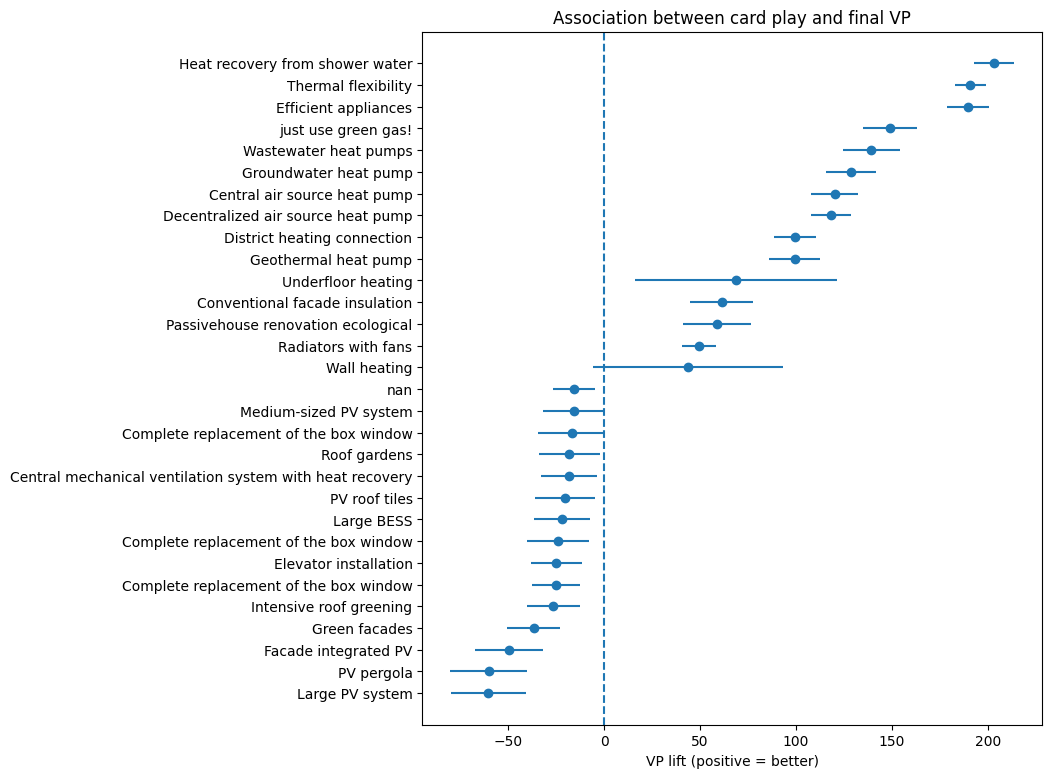

In [8]:
plot_card_vp_lift(cards, top_n=30)
plt.show()

## 5. Which cards are disproportionately represented in elite games?

This comparison separates **frequency** from **success association**.

A card can be very common overall but not especially important for elite games. Conversely, a rare card can have a high enrichment ratio if it appears disproportionately often among the best-performing games.

In the scatter plot:

- the diagonal represents equal occurrence in all and elite games,
- cards above the diagonal are overrepresented among elite games,
- cards below the diagonal are underrepresented.


In [9]:
cards.sort_values("enrichment", ascending=False)[columns].head(20)

,card,label_en,category,occurrence,elite_occurrence,enrichment,vp_lift,vp_lift_ci_low,vp_lift_ci_high
0,green_gas,just use green gas!,Wärmeerzeugung,0.0786,0.546,6.946565,148.881599,134.877591,162.885607
1,bidirectional_charging,Bidirectional charging,*Flexibilität,0.0802,0.242,3.017456,38.406103,21.483209,55.328996
2,ev_charging_infrastructure,E-car charging infrastructure,*Zufriedenheit,0.1053,0.276,2.621083,40.030202,25.083278,54.977125
3,shower_water_heat_recovery,Heat recovery from shower water,*Effizienz,0.0694,0.136,1.959654,203.157216,192.611273,213.703158
4,groundwater_heat_pump,Groundwater heat pump,Wärmeerzeugung,0.0796,0.116,1.457286,128.624548,115.462847,141.786250
5,efficient_appliances,Efficient appliances,*Flexibilität,0.0736,0.098,1.331522,189.660260,178.822952,200.497568
6,conventional_facade_insulation_2,Conventional facade insulation,Dämmung,0.0589,0.076,1.290323,61.235477,44.870116,77.600839
7,thermal_flexibility,Thermal flexibility,*Flexibilität,0.3351,0.368,1.098180,190.864941,182.894821,198.835061
8,wastewater_heat_pump,Wastewater heat pumps,Wärmeerzeugung,0.0529,0.058,1.096408,139.335212,124.362506,154.307918
9,ev_wallboxes,E-car wall boxes,*Zufriedenheit,0.2067,0.204,0.986938,23.442391,12.411427,34.473355


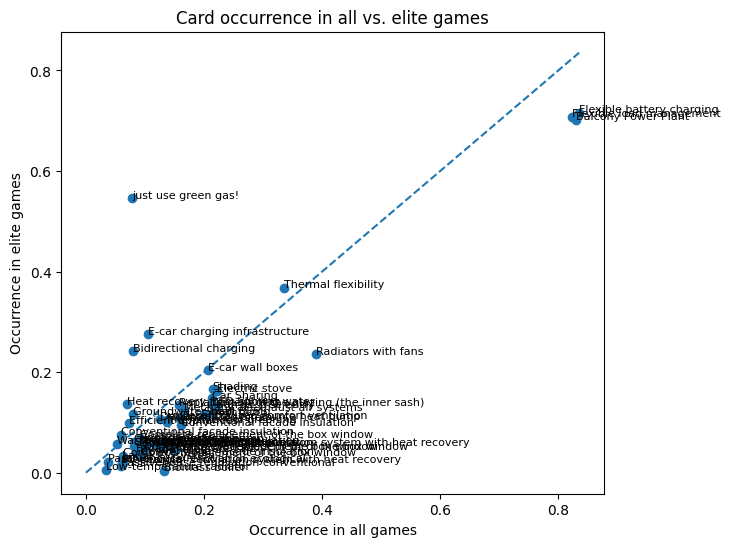

In [10]:
plot_card_enrichment(
    cards,
    min_occurrence=0.02,
)
plt.show()

## 6. Opportunity-adjusted card selection

This section requires `plays.parquet`, generated with:

```python
run_simulation(
    version,
    ...,
    log_choices=True,
)
```

The analysis counts a logical card only once per decision, even if several physical copies of that card were present.

This is useful for answering:

> When the card was actually playable, how often was it selected?


In [11]:
if plays.empty:
    print("No detailed play log available. Re-run the simulation with log_choices=True.")
else:
    opportunities = card_opportunity_summary(plays)

    opportunity_view = cards.merge(
        opportunities,
        on="card",
        how="left",
        suffixes=("", "_check"),
    )

    columns = [
        "card",
        "label_en",
        "playable_opportunities",
        "selected",
        "selection_rate",
        "vp_lift",
        "enrichment",
    ]

    columns = [c for c in columns if c in opportunity_view.columns]

    display(
        opportunity_view
        .sort_values("selection_rate", ascending=False)[columns]
        .head(30)
    )

,card,label_en,playable_opportunities,selected,selection_rate,vp_lift,enrichment
30,fan_assisted_radiators,Radiators with fans,19746,3899,0.197458,49.320183,0.605283
1,bidirectional_charging,Bidirectional charging,4132,802,0.194095,38.406103,3.017456
7,thermal_flexibility,Thermal flexibility,17887,3351,0.187343,190.864941,1.098180
11,flexible_battery_charging,Flexible battery charging,66056,8353,0.126453,5.597266,0.857177
13,balcony_pv,Balcony Power Plant,66385,8302,0.125058,6.211623,0.845579
10,flexible_load_management,Flexible load management,66833,8227,0.123098,14.586776,0.860581
5,efficient_appliances,Efficient appliances,18628,736,0.039510,189.660260,1.331522
3,shower_water_heat_recovery,Heat recovery from shower water,18589,694,0.037334,203.157216,1.959654
31,barrier_free_entry,Barrier_free entry,67050,2210,0.032960,0.697281,0.597285
52,low_temperature_radiator,Low-temperature radiator,10411,343,0.032946,6.951514,0.174927


## 7. When are cards played?

Timing can help distinguish:

- **foundation cards** that are normally selected early,
- **late optimisation cards**,
- cards that only become available after prerequisites are met.

This section also requires `log_choices=True`.


In [12]:
if plays.empty:
    print("No detailed play log available.")
else:
    timing = card_round_summary(plays)

    timing = timing.merge(
        cards[["card", "label_en"]].drop_duplicates(),
        on="card",
        how="left",
    )

    timing.sort_values(
        ["median_round", "times_played"],
        ascending=[True, False],
    ).head(40)

## 8. Sensitivity to the elite-game cutoff

A card should not be called important solely because it performs well under one arbitrary cutoff.

The following table repeats the enrichment analysis for the best:

- 1%
- 5%
- 10%

A robust card should generally remain positively enriched across several cutoffs.


In [13]:
sensitivity = card_elite_sensitivity(
    games,
    elite_shares=(0.01, 0.05, 0.10),
)

card_info = cards[
    ["card", "label_en", "category"]
].drop_duplicates()

sensitivity = sensitivity.merge(
    card_info,
    on="card",
    how="left",
)

sensitivity.head()

,card,occurrence,elite_occurrence,enrichment,elite_difference,elite_share,label_en,category
0,BESS_large,0.1176,0.12,1.020408,0.0024,0.01,Large BESS,*Flexibilität
1,BESS_small,0.2004,0.15,0.748503,-0.0504,0.01,Small BESS,*Flexibilität
2,BIPV,0.0840,0.05,0.595238,-0.0340,0.01,Facade integrated PV,*Effizienz
3,add_balcony,0.2123,0.09,0.423928,-0.1223,0.01,NaN,*Zufriedenheit
4,balcony_pv,0.8302,0.87,1.047940,0.0398,0.01,Balcony Power Plant,*Effizienz


In [14]:
sensitivity_pivot = sensitivity.pivot(
    index=["card", "label_en"],
    columns="elite_share",
    values="enrichment",
)

sensitivity_pivot.columns = [
    f"enrichment_{share:.0%}"
    for share in sensitivity_pivot.columns
]

sensitivity_pivot.sort_values(
    "enrichment_5%",
    ascending=False,
).head(30)

,,enrichment_1%,enrichment_5%,enrichment_10%
card,label_en,,,
green_gas,just use green gas!,4.707379,6.946565,3.625954
bidirectional_charging,Bidirectional charging,7.605985,3.017456,1.932668
ev_charging_infrastructure,E-car charging infrastructure,6.552707,2.621083,1.861349
shower_water_heat_recovery,Heat recovery from shower water,2.881844,1.959654,1.945245
groundwater_heat_pump,Groundwater heat pump,2.261307,1.457286,1.557789
efficient_appliances,Efficient appliances,2.173913,1.331522,1.616848
conventional_facade_insulation_2,Conventional facade insulation,1.018676,1.290323,1.205433
thermal_flexibility,Thermal flexibility,1.760668,1.098180,1.310057
wastewater_heat_pump,Wastewater heat pumps,1.134216,1.096408,1.531191


## 9. Candidate cards for closer inspection

For the paper, the most interesting cards are likely those where several indicators point in the same direction.

A strong candidate would typically show:

- positive VP lift,
- enrichment above 1,
- sufficient occurrence to avoid being driven by a handful of games,
- and, where logged, a meaningful selection rate.

The following is only a convenient screening table, not a statistical decision rule.


In [15]:
candidate_cards = cards.copy()

candidate_cards = candidate_cards.loc[
    (candidate_cards["occurrence"] >= 0.02)
    & (candidate_cards["enrichment"] > 1)
    & (candidate_cards["vp_lift"] > 0)
]

candidate_columns = [
    "card",
    "label_en",
    "category",
    "occurrence",
    "elite_occurrence",
    "enrichment",
    "vp_lift",
    "vp_lift_ci_low",
    "vp_lift_ci_high",
    "median_round",
    "selection_rate",
]

candidate_columns = [
    c for c in candidate_columns
    if c in candidate_cards.columns
]

candidate_cards[
    candidate_columns
].sort_values(
    ["enrichment", "vp_lift"],
    ascending=False,
)

,card,label_en,category,occurrence,elite_occurrence,enrichment,vp_lift,vp_lift_ci_low,vp_lift_ci_high,median_round,selection_rate
0,green_gas,just use green gas!,Wärmeerzeugung,0.0786,0.546,6.946565,148.881599,134.877591,162.885607,2.0,0.021224
1,bidirectional_charging,Bidirectional charging,*Flexibilität,0.0802,0.242,3.017456,38.406103,21.483209,55.328996,3.0,0.194095
2,ev_charging_infrastructure,E-car charging infrastructure,*Zufriedenheit,0.1053,0.276,2.621083,40.030202,25.083278,54.977125,2.0,0.023416
3,shower_water_heat_recovery,Heat recovery from shower water,*Effizienz,0.0694,0.136,1.959654,203.157216,192.611273,213.703158,3.0,0.037334
4,groundwater_heat_pump,Groundwater heat pump,Wärmeerzeugung,0.0796,0.116,1.457286,128.624548,115.462847,141.786250,2.0,0.021494
5,efficient_appliances,Efficient appliances,*Flexibilität,0.0736,0.098,1.331522,189.660260,178.822952,200.497568,3.0,0.039510
6,conventional_facade_insulation_2,Conventional facade insulation,Dämmung,0.0589,0.076,1.290323,61.235477,44.870116,77.600839,2.0,0.020405
7,thermal_flexibility,Thermal flexibility,*Flexibilität,0.3351,0.368,1.098180,190.864941,182.894821,198.835061,2.0,0.187343
8,wastewater_heat_pump,Wastewater heat pumps,Wärmeerzeugung,0.0529,0.058,1.096408,139.335212,124.362506,154.307918,2.0,0.020033


## 10. Strategy comparison

This becomes relevant once additional strategies such as `cheapskate`, `collector`, `electrician`, `insulator`, or `user_first` are simulated.

If all strategies are stored together in `games`, this table compares their final outcomes directly.


In [16]:
if "strategy" in games.columns and games["strategy"].nunique() > 1:
    display(strategy_summary(games))
else:
    print("Only one strategy is currently present in the simulation results.")

Only one strategy is currently present in the simulation results.


## 11. Interpretation checklist for the paper

Before calling a card "effective", check whether the following agree:

1. **Occurrence:** Is there enough simulation exposure to estimate anything reliably?
2. **Elite enrichment:** Is the card overrepresented among good games?
3. **VP lift:** Are games containing the card associated with lower final VP?
4. **Confidence interval:** Is the estimated association reasonably precise?
5. **Opportunity:** Was the card actually available often enough?
6. **Selection rate:** Do simulated strategies choose it when it is playable?
7. **Timing:** Is its apparent value dependent on early or late play?
8. **Sensitivity:** Does the result persist for 1%, 5%, and 10% elite cutoffs?
9. **Strategy dependence:** Does the conclusion persist across different player strategies?

Only after these checks should pairwise interactions or more advanced counterfactual card-value analysis be added.
